# Capstone 2: Business Analysis with Python
## Sales Territory Analysis
This project analyzes sales performance, customer activity, and product trends for Emporium.
The analysis compares sales performance between Florida and Texas within the South reigon.

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [137]:
products = pd.read_csv('/content/Products.csv')
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [138]:
product_categories = pd.read_csv('/content/ProductCategories.csv')
product_categories.info()
product_categories.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [139]:
store_detail = pd.read_csv('/content/StoreDetail.csv')
store_detail.info()
store_detail.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [140]:
store_sales = pd.read_csv('/content/StoreSales.csv')
store_sales.info()
store_sales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [141]:
customer_list = pd.read_csv('/content/customer_list.csv', sep='|')
customer_list.info()
customer_list.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


# Core Marketing Analysis

## Territory Managers and Store Location

In [142]:
south_region = store_detail[store_detail['Region'] == 'South']

south_region[['Store ID', 'Store Location', 'State', 'Territory Manager']]

,Store ID,Store Location,State,Territory Manager
26,719,Cape Canaveral,Florida,Lana Ilana
27,720,Fort Lauderdale,Florida,Lana Ilana
28,721,Jacksonville,Florida,Lana Ilana
29,722,Key West,Florida,Lana Ilana
30,723,Lakeland,Florida,Lana Ilana
31,724,Miami,Florida,Lana Ilana
32,725,Naples,Florida,Lana Ilana
33,726,Orlando,Florida,Lana Ilana
34,727,Sebring,Florida,Lana Ilana
35,728,Tallahassee,Florida,Lana Ilana


The sales territory manager for Texas is Jeff "Howdy" Richards. For Florida it is Lana llana.

## Monthly Revenue

In [143]:
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')
#Creating year & month columns
sales_detail = pd.merge(store_sales, store_detail, on='Store ID')

south_states = ['Texas', 'Florida']
sales_detail = sales_detail[sales_detail['State'].isin(south_states)].copy()

monthly_revenue = sales_detail.groupby(['State', 'Month'])['Sale Amount'].sum() .reset_index()
monthly_revenue


,State,Month,Sale Amount
0,Florida,2022-01,48143.95
1,Florida,2022-02,46257.35
2,Florida,2022-03,53541.25
3,Florida,2022-04,49505.25
4,Florida,2022-05,58326.64
...,...,...,...
91,Texas,2025-08,98630.93
92,Texas,2025-09,109065.94
93,Texas,2025-10,168955.72
94,Texas,2025-11,105400.74


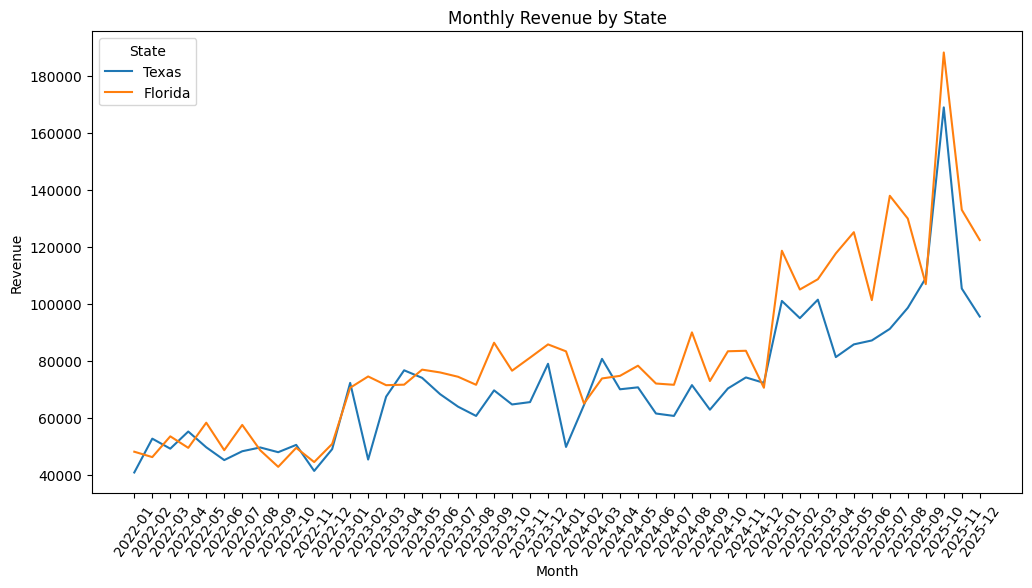

In [144]:
texas = monthly_revenue[
    monthly_revenue['State'] == 'Texas'
]
florida = monthly_revenue[
    monthly_revenue['State'] == 'Florida'
]


plt.figure(figsize=(12,6))



plt.plot(
    texas['Month'].astype(str),
    texas['Sale Amount'],
    color='tab:blue',
    label='Texas'
)
plt.plot(
    florida['Month'].astype(str),
    florida['Sale Amount'],
    color='tab:orange',
    label='Florida'
)

plt.title('Monthly Revenue by State')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=55)

plt.legend(title='State')

plt.show()

Florida generated higher monthly revenue than Texas for most of the analyzed period.

## Store Performance Rankings

In [145]:
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

sales_detail = pd.merge(store_sales, store_detail, on='Store ID')

south_states = ['Texas', 'Florida']
sales_detail = sales_detail[sales_detail['State'].isin(south_states)]

monthly_revenue = sales_detail.groupby(['State', 'Month'])['Sale Amount'].sum() .reset_index()
monthly_revenue

,State,Month,Sale Amount
0,Florida,2022-01,48143.95
1,Florida,2022-02,46257.35
2,Florida,2022-03,53541.25
3,Florida,2022-04,49505.25
4,Florida,2022-05,58326.64
...,...,...,...
91,Texas,2025-08,98630.93
92,Texas,2025-09,109065.94
93,Texas,2025-10,168955.72
94,Texas,2025-11,105400.74


In [146]:
sales_detail = pd.merge(
    store_sales,
    store_detail,
    on='Store ID')
south_sales = sales_detail[sales_detail['Region'] == 'South']
store_rankings = south_sales.groupby(['State', 'Store ID', 'Store Location'])['Sale Amount'].sum().sort_values(ascending=False)
store_rankings.head(10)

State           Store ID  Store Location
Texas           905       Beaumont          637818.90
Florida         724       Miami             618846.25
                728       Tallahassee       541670.66
Texas           910       Fort Worth        351772.59
South Carolina  853       Greenville        337002.00
Florida         722       Key West          332620.43
                719       Cape Canaveral    331956.13
                721       Jacksonville      331667.08
                727       Sebring           330848.14
Texas           909       Desoto            330720.12
Name: Sale Amount, dtype: float64

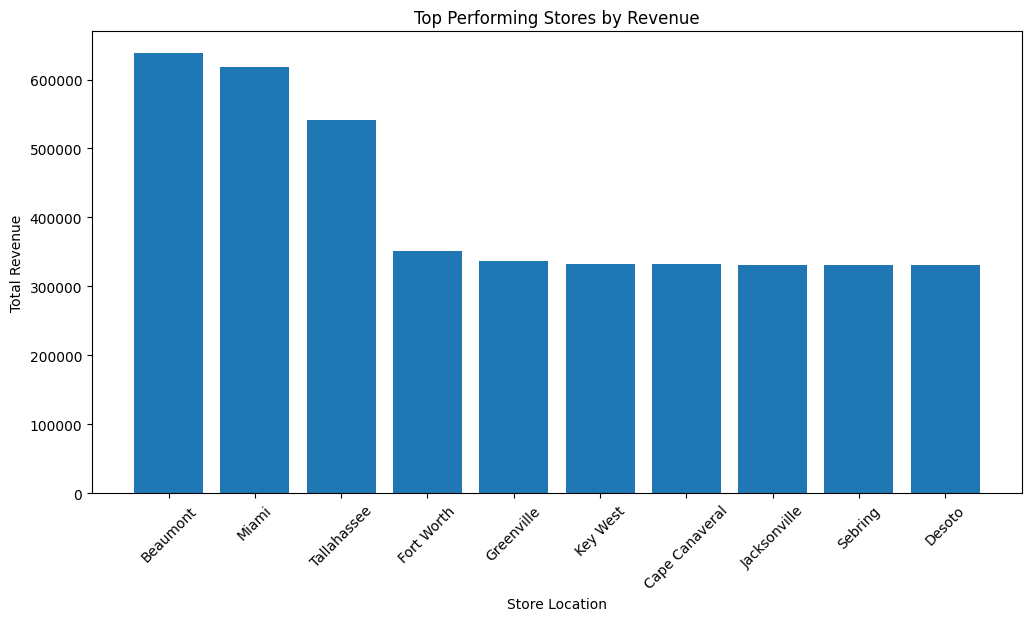

In [147]:
top_stores = store_rankings.head(10).reset_index()
plt.figure(figsize=(12,6))

plt.bar(top_stores['Store Location'],
        top_stores['Sale Amount'])

plt.title('Top Performing Stores by Revenue')
plt.xlabel('Store Location')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

Beaumont, Texas is the highest performing store overall, generating more than $637,000 in total sales revenue.

## Top Customers

In [148]:
south_sales = sales_detail[sales_detail['Region'] == 'South']
customer_sales = pd.merge(customer_list,
                          south_sales,
                          left_on='cust_id',
                          right_on='RewardsID',
                          how='inner')

In [149]:
top_customers = customer_sales.groupby(
    ['State', 'cust_id', 'name'])['Sale Amount'].sum().sort_values(ascending=False)

print('Top Texas Customers')
display(top_customers.loc['Texas'].head(5))

print('Top Florida Customers')
display(top_customers.loc['Florida'].head(5))

Top Texas Customers


,,Sale Amount
cust_id,name,
344,Nate Jacobs,5240.86
474,Christopher Moltisanti,3479.46
102,Jodie L.,3464.91
168,Darius,3400.35
271,Maeby F.,3127.53


Top Florida Customers


,,Sale Amount
cust_id,name,
47,Stanley H.,4954.99
259,Todd Chavez,4549.16
190,Huck,4415.78
335,John Locke,3631.94
164,Dr. Ray Flemming,3535.88


The analysis identified several rewards members with high total purchase amounts across both states.

In [150]:
sales_products = pd.merge(store_sales, products, on='Prod Num')
full_sales_products = pd.merge(sales_products, product_categories, on=['CategoryID'])

full_sales_products

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Product,CategoryID,SubcategoryID_x,Category,SubcategoryID_y,Subcategory
0,2022-01-01,702,NaN,105349-M,8.00,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,130-off,Office and Study Supplies
1,2022-01-01,702,NaN,105349-M,8.00,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,130-clo,"Clothing (T-Shirts, Hoodies, and Jackets)"
2,2022-01-01,702,NaN,105349-M,8.00,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,130-tec,Technology Accessories
3,2022-01-01,702,NaN,105349-M,8.00,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,130-hom,Home and Decor
4,2022-01-01,702,NaN,105349-M,8.00,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,130-hat,Hats and Caps
...,...,...,...,...,...,...,...,...,...,...,...,...
2976628,2025-12-31,910,NaN,105300-IT,77.81,2025-12,AVerMedia Live Streamer CAM 513,120,120-ext,Technology & Accessories,120-sof,Software Download
2976629,2025-12-31,910,NaN,105300-IT,77.81,2025-12,AVerMedia Live Streamer CAM 513,120,120-ext,Technology & Accessories,120-hea,Headphones
2976630,2025-12-31,910,NaN,105300-IT,77.81,2025-12,AVerMedia Live Streamer CAM 513,120,120-ext,Technology & Accessories,120-ext,External Accessories
2976631,2025-12-31,910,NaN,105300-IT,77.81,2025-12,AVerMedia Live Streamer CAM 513,120,120-ext,Technology & Accessories,120-cha,Chargers and Power Adapters


## Number of Transactions Per Month by Product Category


In [151]:
transactions = full_sales_products.merge(store_detail[['Store ID', 'State']], on='Store ID')

transactions = transactions[transactions['State'].isin(['Texas', 'Florida'])]

transactions = transactions.groupby(['State', 'Category', 'Month']).size().reset_index(name='Transaction Count')
transactions

,State,Category,Month,Transaction Count
0,Florida,Apparel and Merchandise,2022-01,528
1,Florida,Apparel and Merchandise,2022-02,488
2,Florida,Apparel and Merchandise,2022-03,424
3,Florida,Apparel and Merchandise,2022-04,472
4,Florida,Apparel and Merchandise,2022-05,504
...,...,...,...,...
571,Texas,Textbooks,2025-08,858
572,Texas,Textbooks,2025-09,814
573,Texas,Textbooks,2025-10,1265
574,Texas,Textbooks,2025-11,792


## Total Sales Revenue Per Month by Category

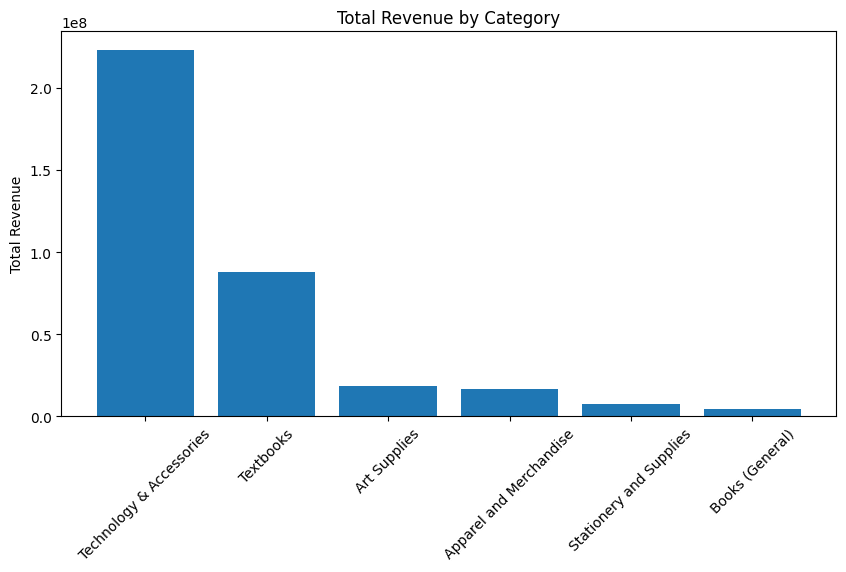

In [152]:
revenue = full_sales_products.groupby('Category', as_index=False)['Sale Amount'].sum()

revenue_sort = revenue.sort_values(by='Sale Amount', ascending=False)

plt.figure(figsize=(10,5))

plt.bar(
    revenue_sort['Category'],
    revenue_sort['Sale Amount']
)

plt.xticks(rotation=45)
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Category")

plt.show()